# scVI Training for DentateGyrus dataset with Genes Removed

In [4]:
0

0

In [2]:
import sys

working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

In [3]:
import copy
import gc
import itertools
import os
import subprocess
import sys
import time
import warnings
from pathlib import Path

import scvelo
import cellrank
import scvi
import anndata as ad
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats
import torch
from sklearn.neighbors import kneighbors_graph
import lightning.pytorch as pl
import torch
import anndata as ad

In [5]:
from helper.random_remove import remove_random_fraction_of_genes

In [6]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

_rcparams_path = "/home/icb/kemal.inecik/work/codes/tardis/training/local/figures/rcparams.pickle"
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)

plt.rcParams.update(_rcparams)

In [7]:
print(f"CUDA used: {torch.cuda.is_available()}")

dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

CUDA used: True


In [8]:
definitions_path = os.path.join(dataset_dir, f"incremental_analysis_definitions_dict.pkl")
with open(definitions_path, "rb") as _file_definitions:
    definitions = pickle.load(_file_definitions)    

In [11]:
def explore_ablation(fraction):
    adata = ad.read_h5ad(definitions["scvi_dentategyrus"]["training_anndata_path"])
    adata.X = adata.layers["counts"].copy()
    del adata.layers["counts"]
    gc.collect()

    adata = remove_random_fraction_of_genes(adata, k=fraction, seed=42)
    
    model_params = dict(
        n_latent=24, 
        gene_likelihood = "nb",
    )
    
    train_params = dict(
        train_size=0.8,
        batch_size=512,
        limit_train_batches=1.00, 
        limit_val_batches=1.00,
        max_epochs=400,
    )
    
    dataset_params = dict(
        layer=None, 
        # labels_key="cell_type",
        # unlabeled_category="NA",
        batch_key="SampleID",
        categorical_covariate_keys=None,
    )
    
    scvi.model.SCVI.setup_anndata(adata, **dataset_params)
    vae = scvi.model.SCVI(adata, **model_params)
    vae.train(**train_params)  # callbacks=[logger_cb]
    
    latent = ad.AnnData(X=vae.get_latent_representation())
    latent.obs = adata.obs.copy()
    sc.pp.neighbors(latent)
    sc.tl.umap(latent)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sc.pl.umap(
            latent,
            color=["Age", "clusters"],
            ncols=4,
            frameon=False,
            legend_fontsize="xx-small",
            legend_loc="on data",
        )

Epoch 61/600:  10%|█         | 60/600 [13:00<1:55:01, 12.78s/it, v_num=9s_1, total_loss_train=2.32e+3, kl_local_train=172, metric_mi|dose_training_train=0.106, metric_mi|condition_train=0.135]

Epoch 61/600:  10%|█         | 61/600 [13:12<1:55:35, 12.87s/it, v_num=9s_1, total_loss_train=2.32e+3, kl_local_train=172, metric_mi|dose_training_train=0.106, metric_mi|condition_train=0.135]

Epoch 61/600:  10%|█         | 61/600 [13:12<1:55:35, 12.87s/it, v_num=9s_1, total_loss_train=2.31e+3, kl_local_train=171, metric_mi|dose_training_train=0.111, metric_mi|condition_train=0.141]

Epoch 62/600:  10%|█         | 61/600 [13:12<1:55:35, 12.87s/it, v_num=9s_1, total_loss_train=2.31e+3, kl_local_train=171, metric_mi|dose_training_train=0.111, metric_mi|condition_train=0.141]

Epoch 62/600:  10%|█         | 62/600 [13:25<1:54:35, 12.78s/it, v_num=9s_1, total_loss_train=2.31e+3, kl_local_train=171, metric_mi|dose_training_train=0.111, metric_mi|condition_train=0.141]

...

Epoch 600/600: 100%|██████████| 600/600 [2:06:01<00:00, 12.36s/it, v_num=9s_1, total_loss_train=2.22e+3, kl_local_train=60.7, metric_mi|dose_training_train=0.146, metric_mi|condition_train=0.166]

Epoch 600/600: 100%|██████████| 600/600 [2:06:01<00:00, 12.36s/it, v_num=9s_1, total_loss_train=2.22e+3, kl_local_train=61, metric_mi|dose_training_train=0.146, metric_mi|condition_train=0.166]  

`Trainer.fit` stopped: `max_epochs=600` reached.


Epoch 600/600: 100%|██████████| 600/600 [2:06:01<00:00, 12.60s/it, v_num=9s_1, total_loss_train=2.22e+3, kl_local_train=61, metric_mi|dose_training_train=0.146, metric_mi|condition_train=0.166]

W&B logger finalized successfully: 
Exit Code: 0



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
You are using a CUDA device ('NVIDIA A100-PCIE-40GB MIG 3g.20gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-e0df68bb-1411-5451-b9de-f747a79c3434]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have man

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


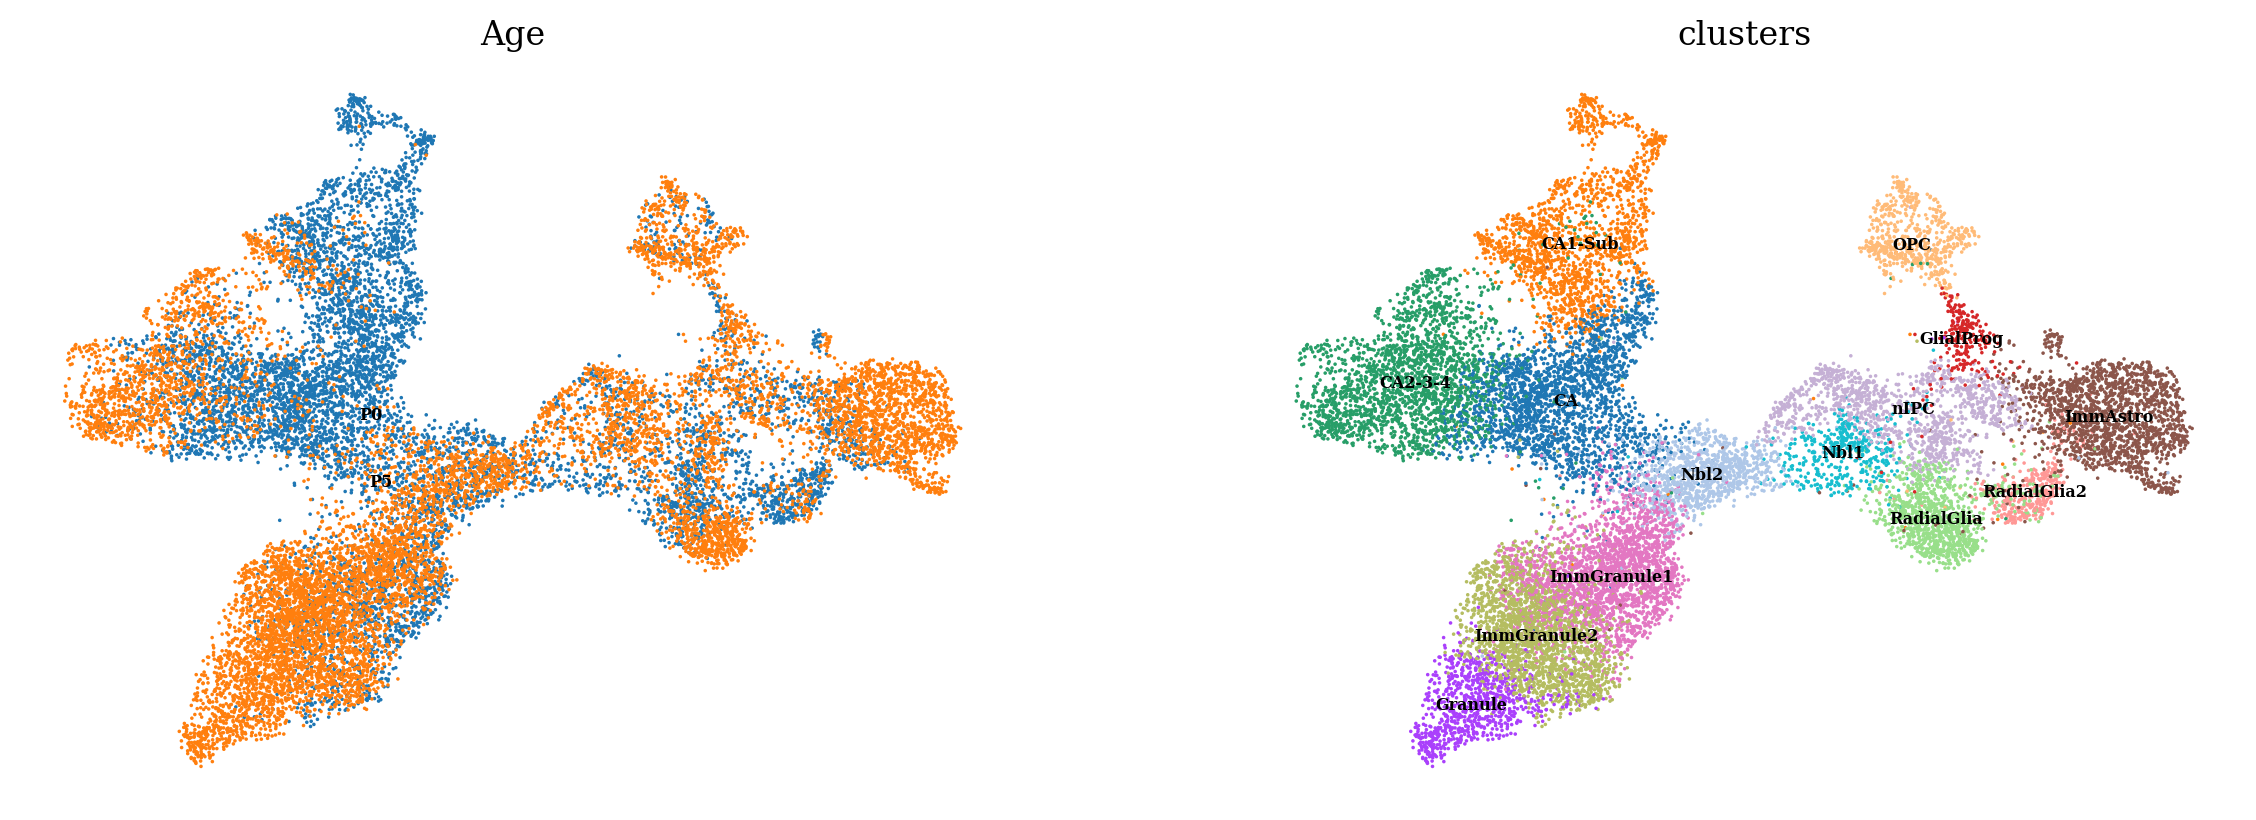

In [12]:
explore_ablation(0.0)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-e0df68bb-1411-5451-b9de-f747a79c3434]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


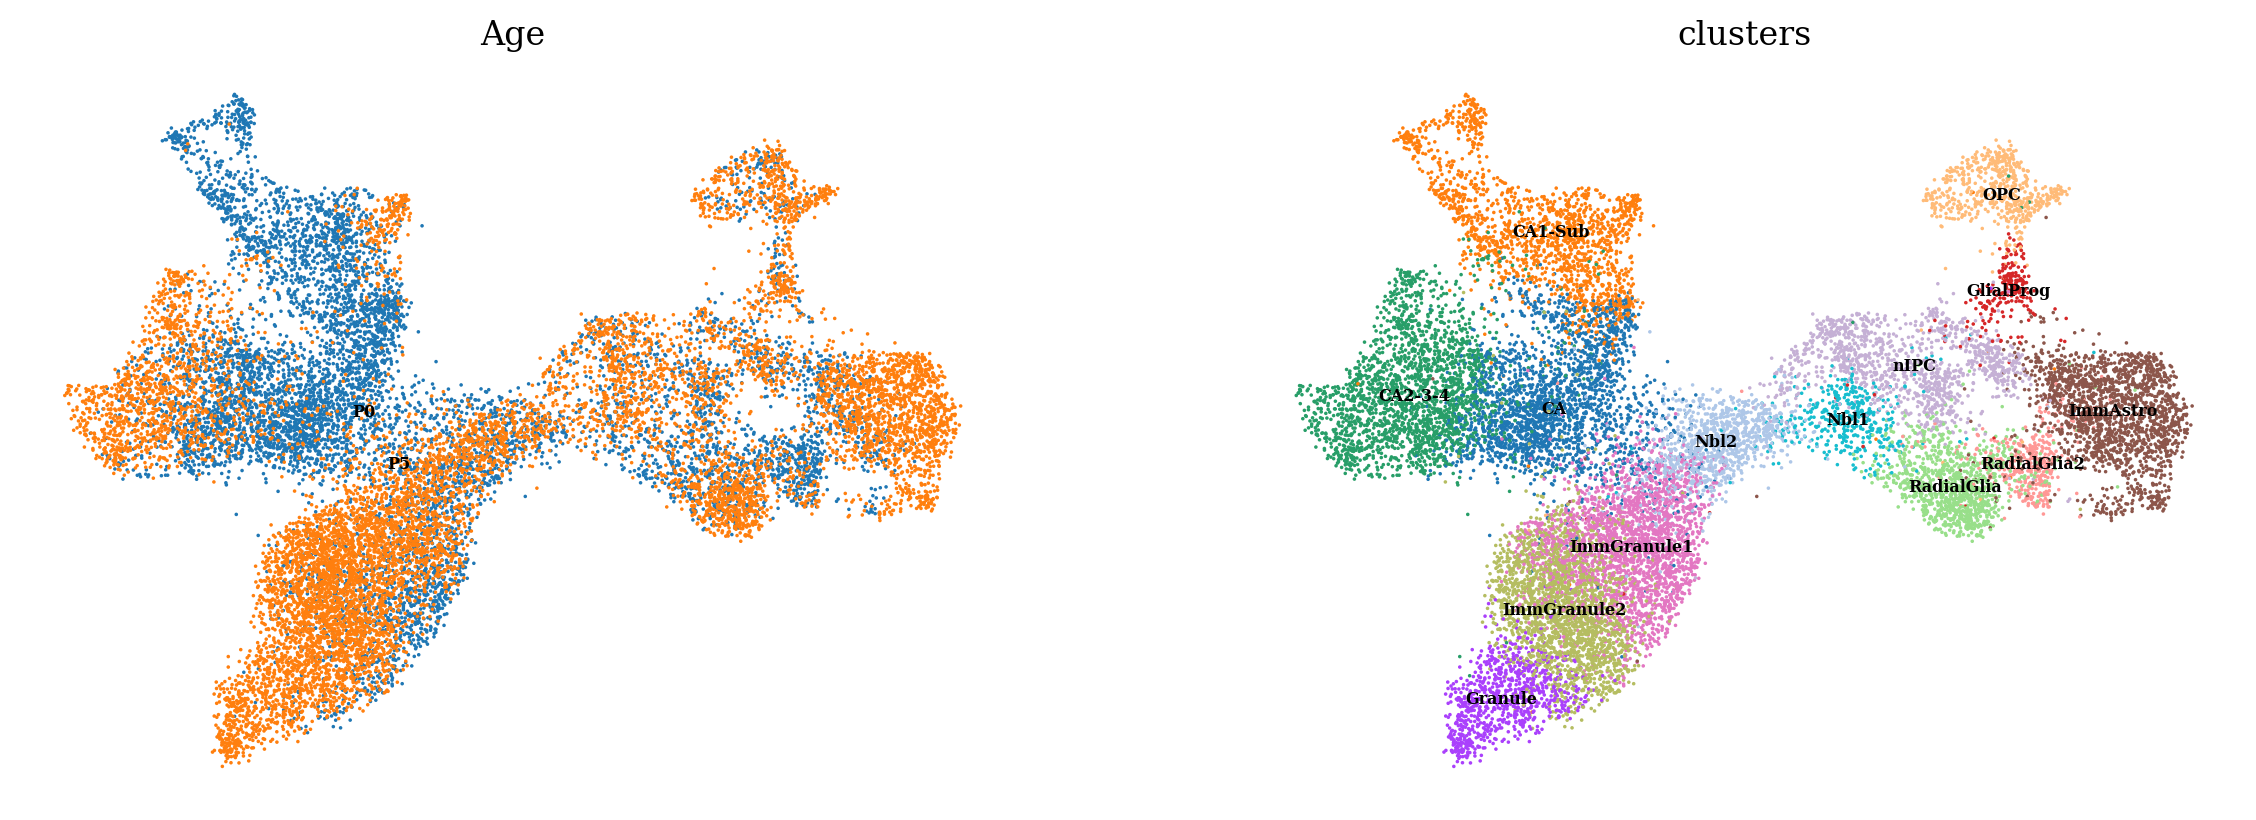

In [13]:
explore_ablation(0.7)

/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


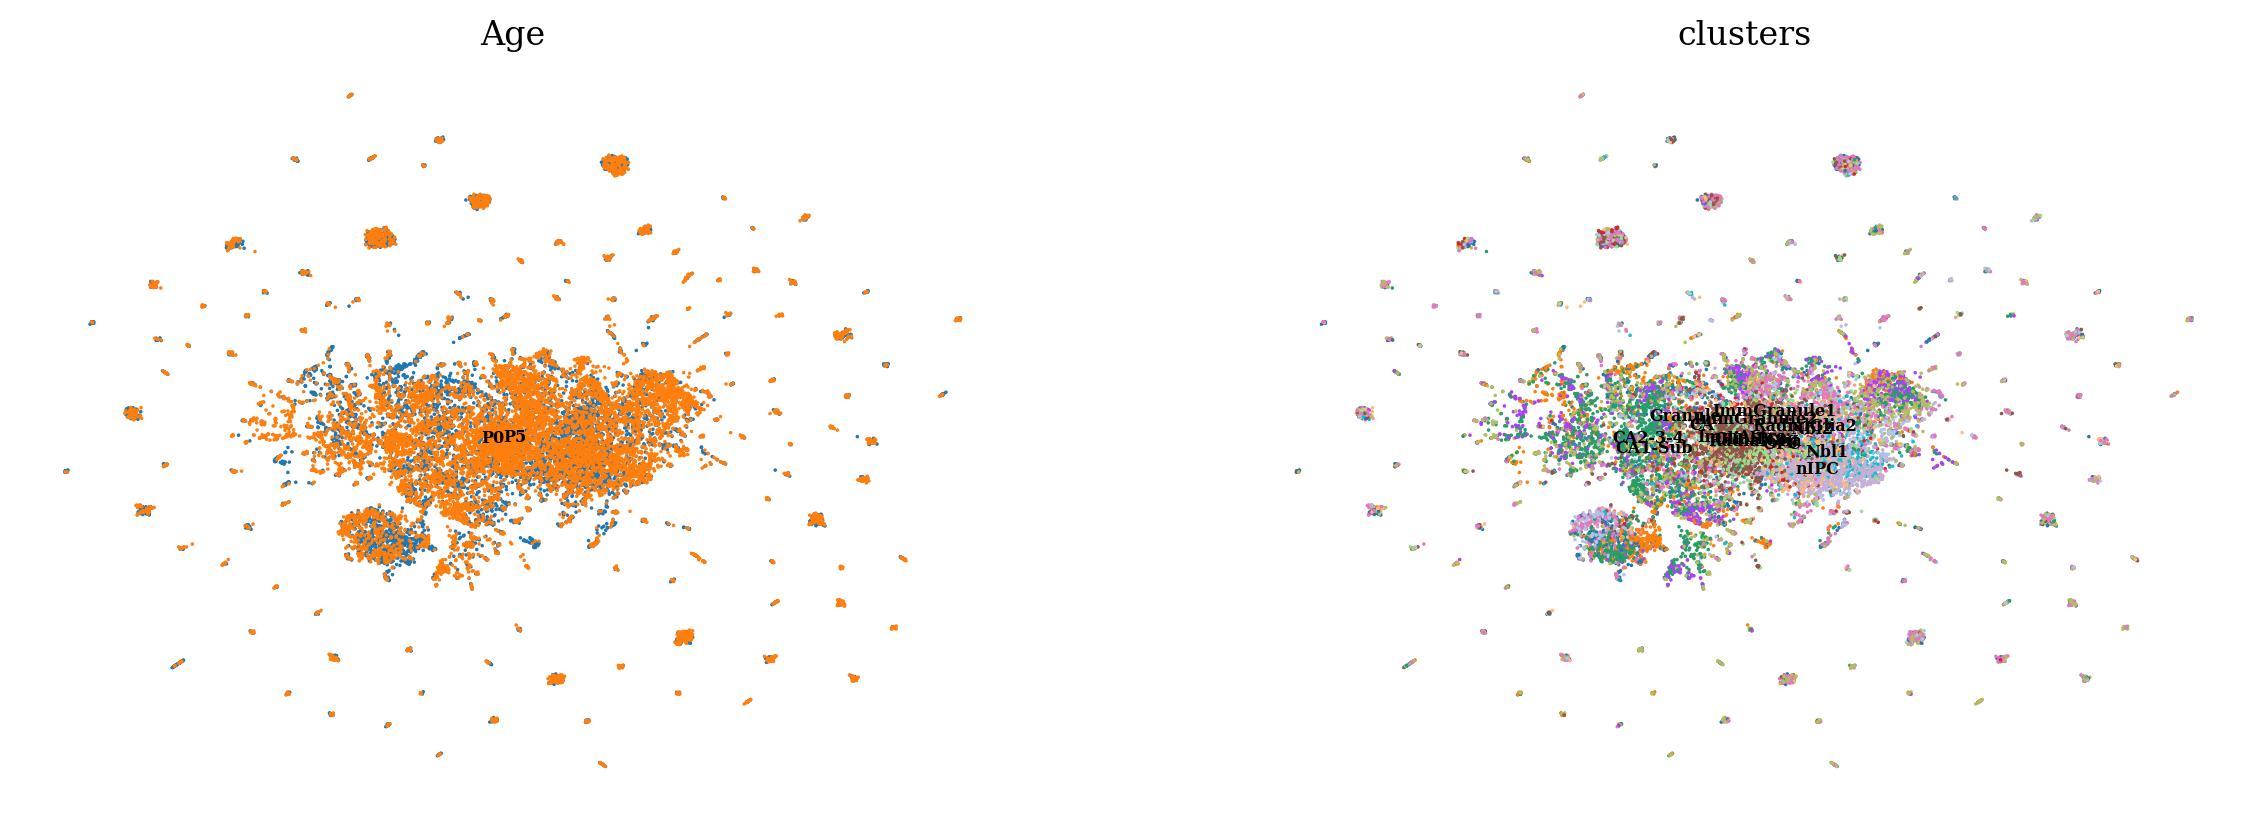

In [14]:
explore_ablation(0.99)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-e0df68bb-1411-5451-b9de-f747a79c3434]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


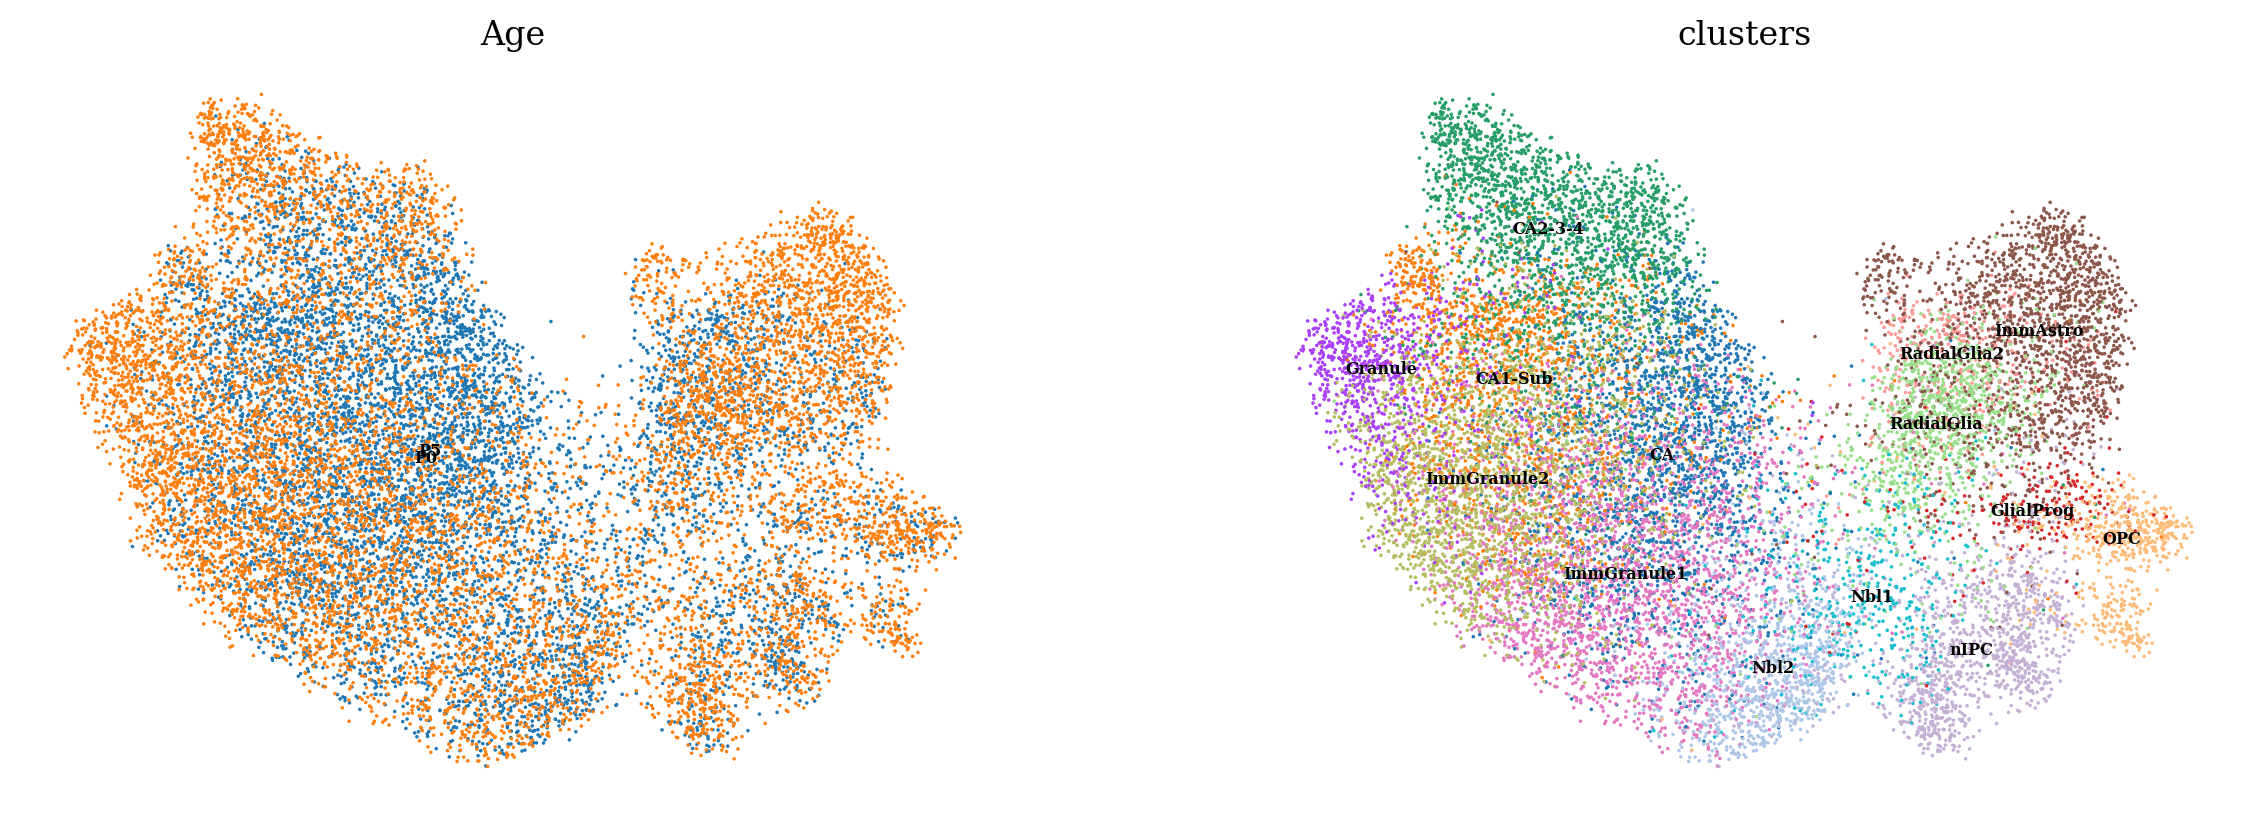

In [15]:
explore_ablation(0.95)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-e0df68bb-1411-5451-b9de-f747a79c3434]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


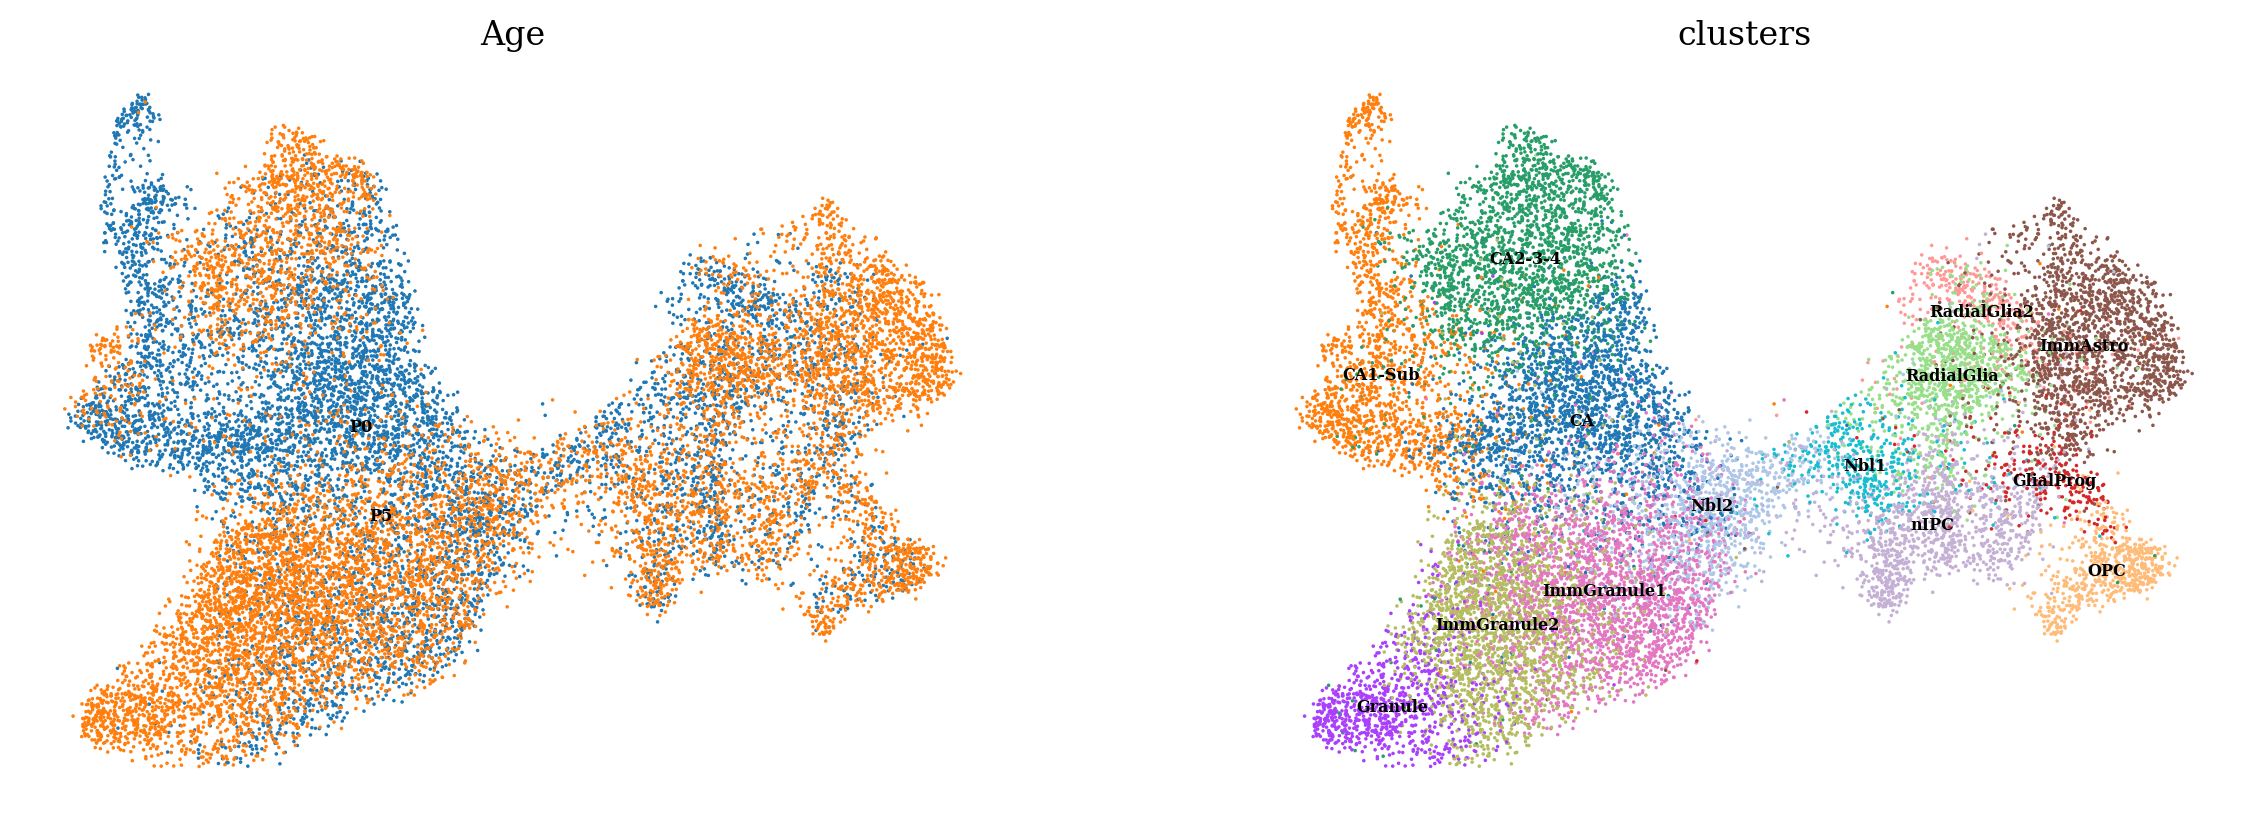

In [16]:
explore_ablation(0.90)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..
`Trainer(limit_val_batches=1.0)` was configured so 100% of the batches will be used..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-e0df68bb-1411-5451-b9de-f747a79c3434]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/icb/kemal.inecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=27` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


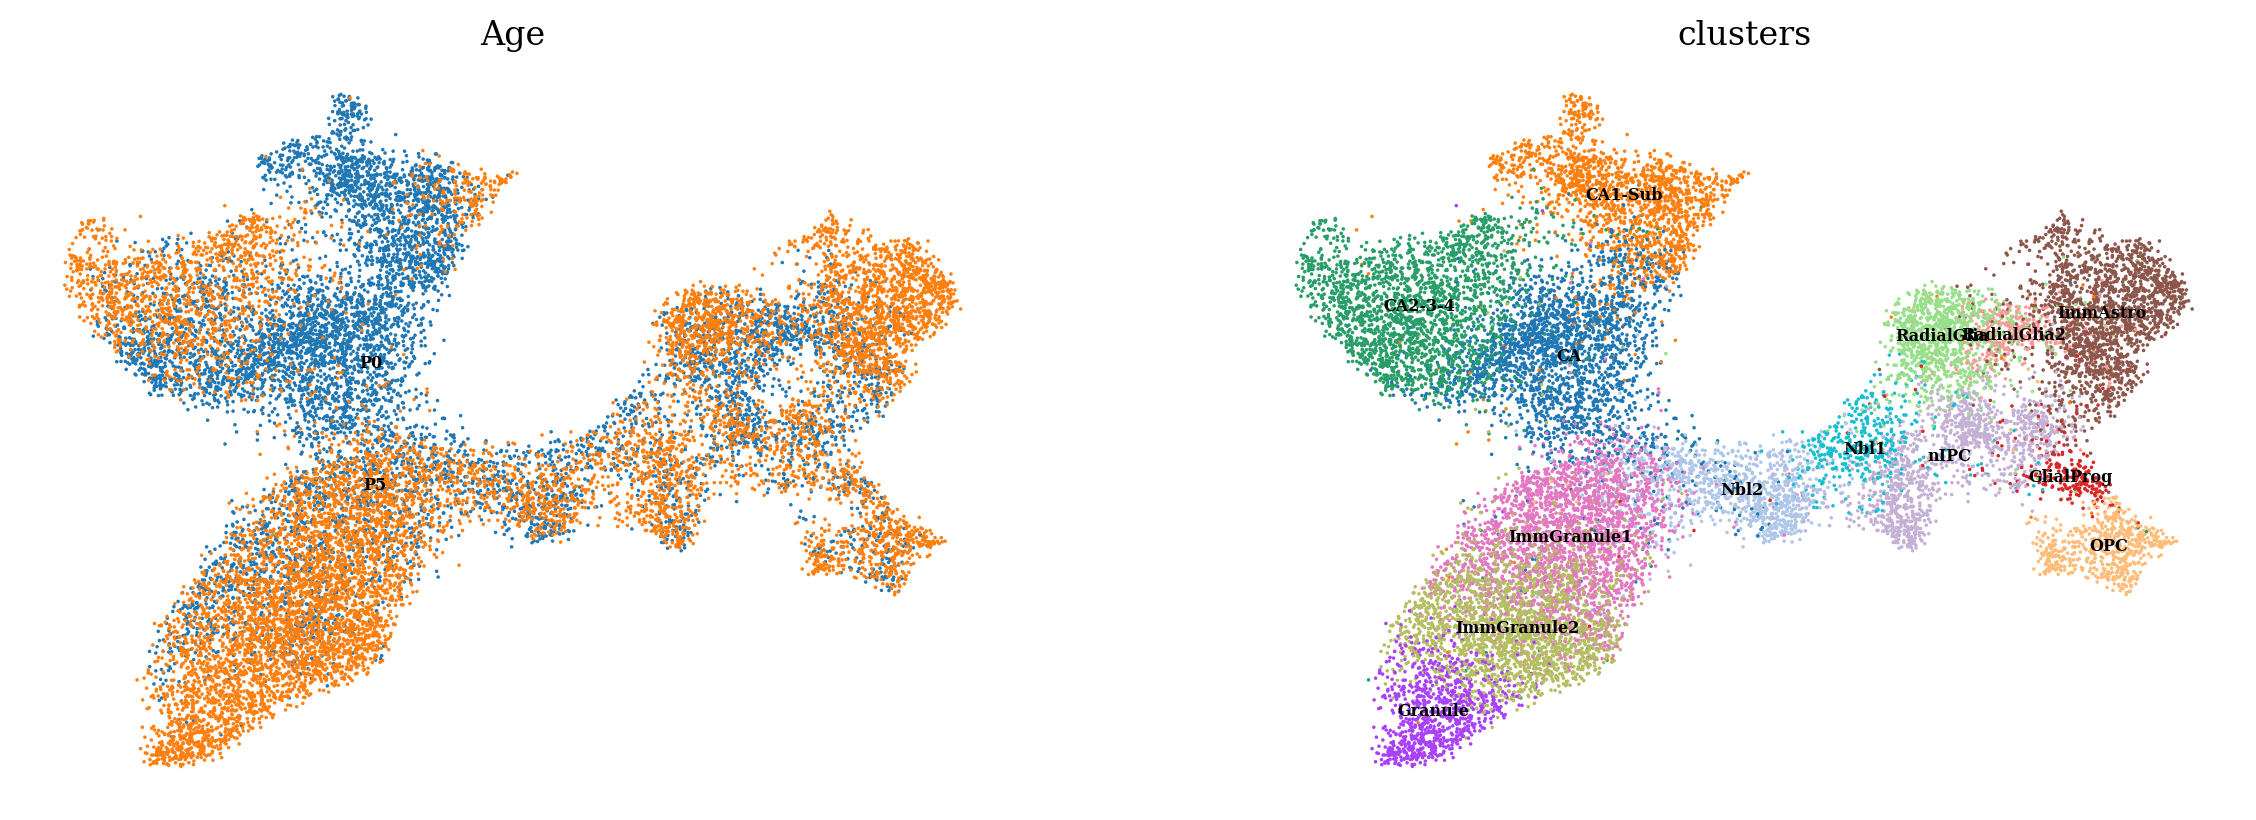

In [17]:
explore_ablation(0.85)

# Run trainings

In [28]:
from decimal import Decimal, getcontext

# set precision high enough for your smallest step
getcontext().prec = 6

def gen_range(start: Decimal, stop: Decimal, step: Decimal):
    vals = []
    cur = start
    # inclusive down to stop (e.g. 0.00)
    while cur >= stop:
        vals.append(cur)
        cur -= step
    return vals

# build your three sequences
seq3 = gen_range(Decimal('1.00'), Decimal('0.00'), Decimal('0.025'))
seq1 = gen_range(Decimal('0.20'), Decimal('0.00'), Decimal('0.0025'))
seq2 = gen_range(Decimal('0.10'), Decimal('0.00'), Decimal('0.0025'))

# union, sort descending, and you already have non-negative values
unique = set(seq1 + seq2 + seq3)
scanning_coefficients = 1 - np.array(sorted(unique, reverse=True))
scanning_coefficients = [float(format(d.normalize(), 'f')) for d in scanning_coefficients ]

print(scanning_coefficients[:10])
print(len(scanning_coefficients))
# scanning_coefficients

[0.0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225]
113


In [29]:
job_count = 0
overwrite = False

paths_dict = dict()


for fraction in scanning_coefficients:

    paths_dict[fraction] = []
    for seed in [1, 2, 3]:
        
        output_dir_path = os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_fraction_{fraction}_seed{seed}.h5ad")
    
        paths_dict[fraction].append(output_dir_path)
        
        log_file = os.path.join(logs_directory, f"slurm_out_scvi_dentategyrus_ablation_gene_fraction_{fraction}_seed{seed}.log")
        job_name = f"sct_abg_{fraction}"
        python_name = f"scvi_dentategyrus_gene_ablation.py"
    
        if overwrite or not os.path.exists(output_dir_path) or not os.path.isfile(output_dir_path):
            try:
                slurm_script = f"""#!/bin/bash
#SBATCH -J {job_name}
#SBATCH -p gpu_p
#SBATCH --qos=gpu_normal
#SBATCH --gres=gpu:1
#SBATCH -c 6
#SBATCH --mem=10G
#SBATCH --nice=0
#SBATCH -t 0:30:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate sctram_dev_env
python -u {os.path.join(helpers_directory, python_name)} --fraction "{fraction}" --seed "{seed}"
"""
                script_name = os.path.join(logs_directory, f"slurm_job_scvi_dentategyrus_ablation_gene_fraction_{fraction}_seed{seed}.sh")
                with open(script_name, "w") as f:
                    f.write(slurm_script)
    
                print(f"Submitted job: scvi_dentategyrus_ablation_gene_fraction_{fraction}_seed{seed}")
                subprocess.run(["sbatch", script_name])
                job_count += 1
                # if job_count>2:
                #     raise ValueError
            finally:
                # time.sleep(0.05)
                os.remove(script_name)
        else:
            print(f"Model exists: scvi_dentategyrus_ablation_gene_fraction_{fraction}_seed{seed}")

print(f" - Number of jobs submitted: {job_count}")

Model exists: scvi_dentategyrus_ablation_gene_fraction_0.0_seed1
Model exists: scvi_dentategyrus_ablation_gene_fraction_0.0_seed2
Model exists: scvi_dentategyrus_ablation_gene_fraction_0.0_seed3
Submitted job: scvi_dentategyrus_ablation_gene_fraction_0.025_seed1
Submitted batch job 36019096
Submitted job: scvi_dentategyrus_ablation_gene_fraction_0.025_seed2
Submitted batch job 36019097
Submitted job: scvi_dentategyrus_ablation_gene_fraction_0.025_seed3
Submitted batch job 36019098
Submitted job: scvi_dentategyrus_ablation_gene_fraction_0.05_seed1
Submitted batch job 36019099
Submitted job: scvi_dentategyrus_ablation_gene_fraction_0.05_seed2
Submitted batch job 36019100
Submitted job: scvi_dentategyrus_ablation_gene_fraction_0.05_seed3
Submitted batch job 36019101
Submitted job: scvi_dentategyrus_ablation_gene_fraction_0.075_seed1
Submitted batch job 36019102
Submitted job: scvi_dentategyrus_ablation_gene_fraction_0.075_seed2
Submitted batch job 36019103
Submitted job: scvi_dentategyrus

In [30]:
_pickle_object = (scanning_coefficients, paths_dict)
_pickle_object_path = os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_settings.pkl")
with open(_pickle_object_path, "wb") as f:
    pickle.dump(_pickle_object, f, protocol=pickle.HIGHEST_PROTOCOL)

In [31]:
1

1